# Exploratory Data Analysis - Bike Sharing Dataset

In this notebook, I conduct a comprehensive Exploratory Data Analysis (EDA) on a public dataset tracking hourly bike rentals. The goal is to clean the raw data and uncover underlying behavioral patterns among riders.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed to ensure reproducibility
np.random.seed(42)

# Ensure the output directory for figures exists
os.makedirs('../figures', exist_ok=True)


## 1. Initial Data Exploration

I began by loading the dataset to inspect its overall structure, dimensions, and the types of variables involved.

In [2]:
# Load the raw dataset
df_raw = pd.read_csv('../data/bike_sharing.csv')

# Check dimensions and column names
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head()


Shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
# Review data types and check for initial null values
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        16500 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         16555 non-null  float64
 13  windspeed   16497 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [4]:
# Generate summary statistics for the numerical features
df_raw.describe().round(2)


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.00,17379.00,17379.0,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,16500.00,17379.00,16555.00,16497.00,17379.00,17379.00,17379.00
mean,8690.00,2.50,0.5,6.54,11.55,0.03,3.00,0.68,1.43,0.50,0.48,0.63,0.19,35.68,153.79,189.46
std,5017.03,1.11,0.5,3.44,6.91,0.17,2.01,0.47,0.64,0.19,0.17,0.19,0.12,49.31,151.36,181.39
min,1.00,1.00,0.0,1.00,0.00,0.00,0.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00,0.00,1.00
25%,4345.50,2.00,0.0,4.00,6.00,0.00,1.00,0.00,1.00,0.34,0.33,0.48,0.10,4.00,34.00,40.00
50%,8690.00,3.00,1.0,7.00,12.00,0.00,3.00,1.00,1.00,0.50,0.48,0.63,0.19,17.00,115.00,142.00
75%,13034.50,3.00,1.0,10.00,18.00,0.00,5.00,1.00,2.00,0.66,0.62,0.78,0.25,48.00,220.00,281.00
max,17379.00,4.00,1.0,12.00,23.00,1.00,6.00,1.00,4.00,1.00,1.00,1.00,0.85,367.00,886.00,977.00


In [5]:
# Identify any exact missing values across the dataset
missing = df_raw.isnull().sum()
print(missing[missing > 0])


temp         879
hum          824
windspeed    882
dtype: int64


## 2. Data Cleaning and Transformations

Before visualizing the data, several cleaning steps were required. This included dropping non-analytical identifiers, parsing datetimes, and handling the missing climate values identified above.

In [6]:
df = df_raw.copy()

# a. Drop the 'instant' index column
df.drop('instant', axis=1, inplace=True)
print('Dropped instant column.')

# b. Convert the date column to a datetime format
df['dteday'] = pd.to_datetime(df['dteday'])
print('Parsed dates.')

# c. Impute missing weather values using the median to avoid skewing
for col in ['temp', 'hum', 'windspeed']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
print('Imputed missing weather values with median.')

# d. Map categorical numerical codes to descriptive strings
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name'] = df['season'].map(season_map)
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
df['weather_name'] = df['weathersit'].map(weather_map)
print('Mapped readable names for seasons and weather.')

# e. Handle extreme rush-hour outliers using the IQR bounds
q1 = df['cnt'].quantile(0.25)
q3 = df['cnt'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers_count = (df['cnt'] > upper_bound).sum()
print(f'Identified {outliers_count} extreme hours (outliers > {upper_bound:.2f}). Capping them to preserve variance.')
df['cnt_capped'] = np.where(df['cnt'] > upper_bound, upper_bound, df['cnt'])


Dropped instant column.
Parsed dates.
Imputed missing weather values with median.
Mapped readable names for seasons and weather.
Identified 505 extreme hours (outliers > 642.50). Capping them to preserve variance.


## 3. Exploratory Visualizations

With the data cleaned, I generated several visualizations to isolate the impacts of seasonality, weather, and time of day on total ridership.

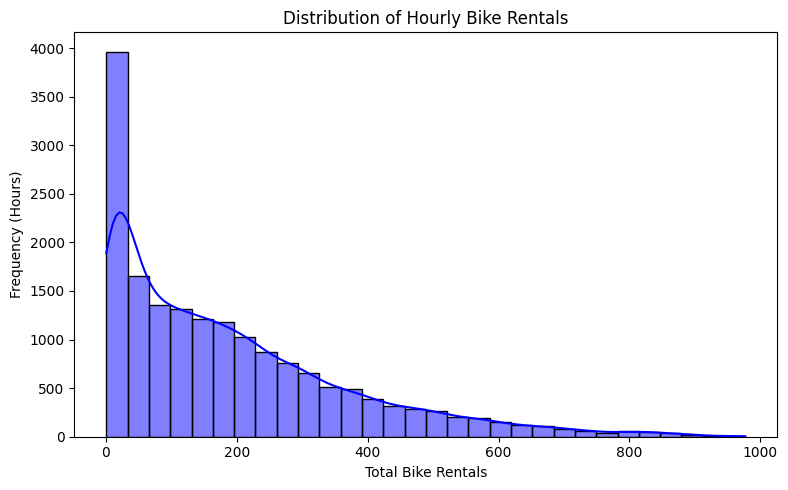

In [7]:
# Plot 1: Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], kde=True, bins=30, color='blue')
plt.title('Distribution of Hourly Bike Rentals')
plt.xlabel('Total Bike Rentals')
plt.ylabel('Frequency (Hours)')
plt.tight_layout()
plt.savefig('../figures/plot1_histogram.png', dpi=200)
plt.show()


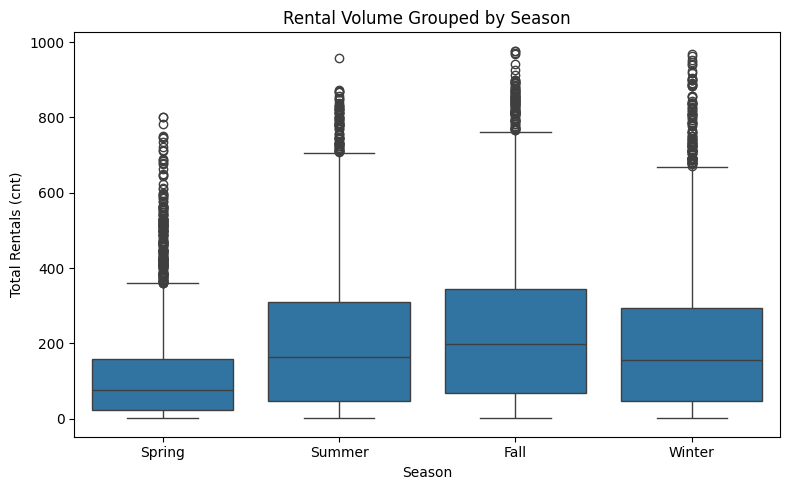

In [8]:
# Plot 2: Boxplot by season
plt.figure(figsize=(8,5))
sns.boxplot(x='season_name', y='cnt', data=df, order=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Rental Volume Grouped by Season')
plt.xlabel('Season')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.savefig('../figures/plot2_boxplot_season.png', dpi=200)
plt.show()


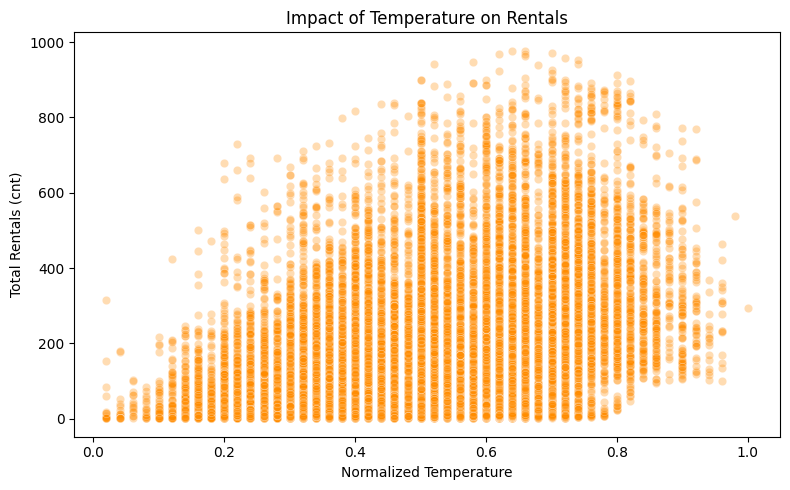

In [9]:
# Plot 3: Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.3, color='darkorange')
plt.title('Impact of Temperature on Rentals')
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.savefig('../figures/plot3_scatter_temp.png', dpi=200)
plt.show()


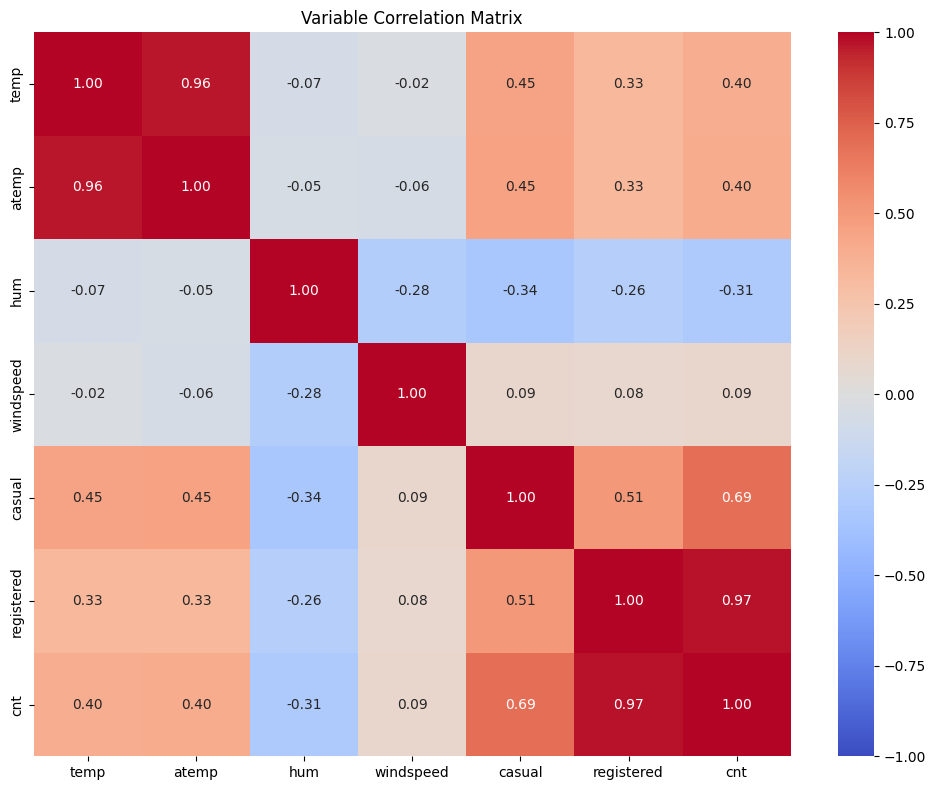

In [10]:
# Plot 4: Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Variable Correlation Matrix')
plt.tight_layout()
plt.savefig('../figures/plot4_heatmap.png', dpi=200)
plt.show()


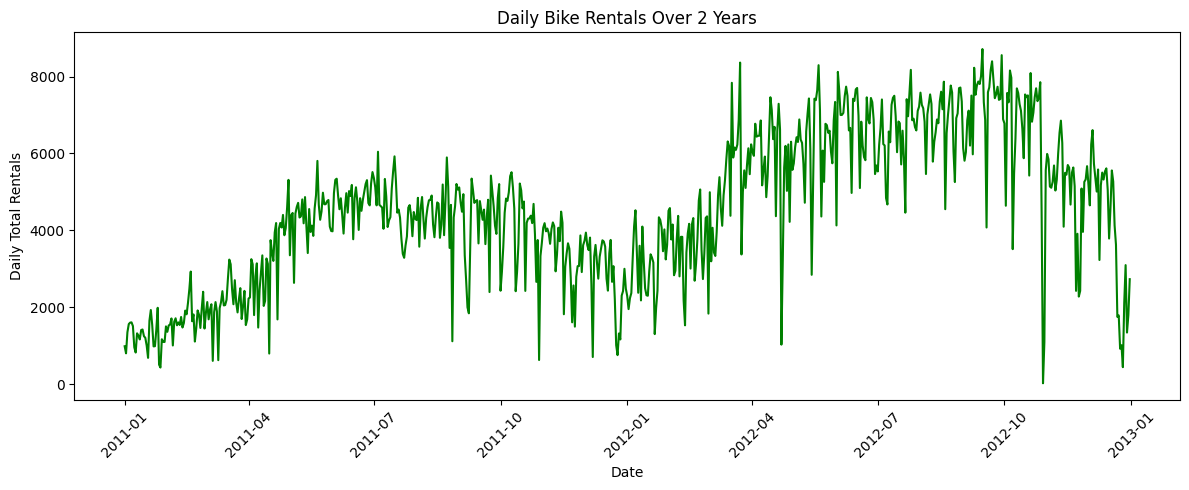

In [11]:
# Plot 5: Time series line plot
daily_counts = df.groupby('dteday')['cnt'].sum().reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(x='dteday', y='cnt', data=daily_counts, color='green')
plt.title('Daily Bike Rentals Over 2 Years')
plt.xlabel('Date')
plt.ylabel('Daily Total Rentals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/plot5_lineplot_trend.png', dpi=200)
plt.show()


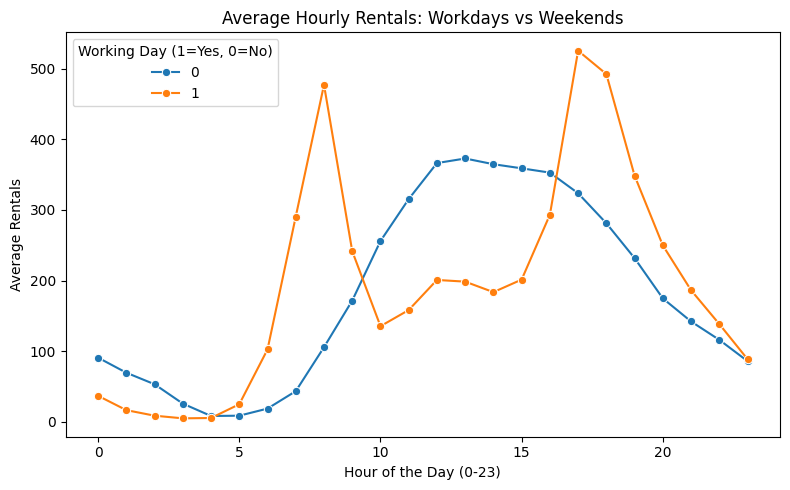

In [12]:
# Plot 6: Grouped Bar plot (Weekday vs Workingday trend)
plt.figure(figsize=(8,5))
hourly_avg = df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
sns.lineplot(x='hr', y='cnt', hue='workingday', data=hourly_avg, marker='o')
plt.title('Average Hourly Rentals: Workdays vs Weekends')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Rentals')
plt.legend(title='Working Day (1=Yes, 0=No)')
plt.tight_layout()
plt.savefig('../figures/plot6_hourly_trend.png', dpi=200)
plt.show()


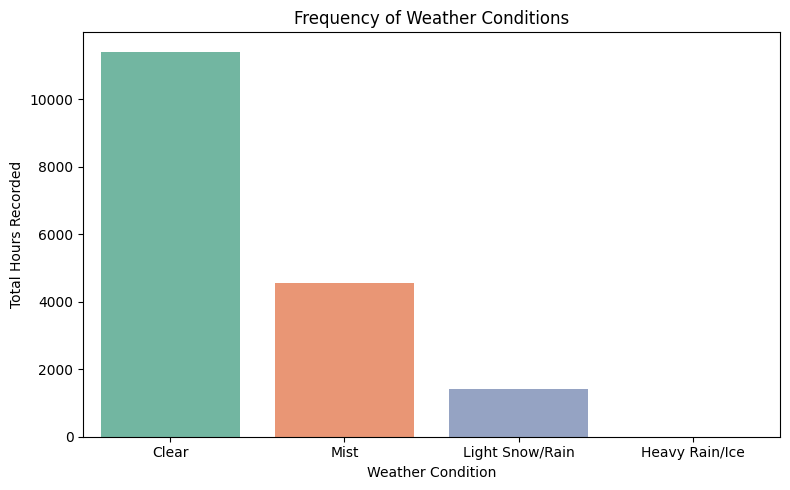

In [13]:
# Plot 7: Count plot
plt.figure(figsize=(8,5))
sns.countplot(x='weather_name', data=df, hue='weather_name', order=['Clear', 'Mist', 'Light Snow/Rain', 'Heavy Rain/Ice'], palette='Set2', legend=False)
plt.title('Frequency of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Total Hours Recorded')
plt.tight_layout()
plt.savefig('../figures/plot7_countplot_weather.png', dpi=200)
plt.show()


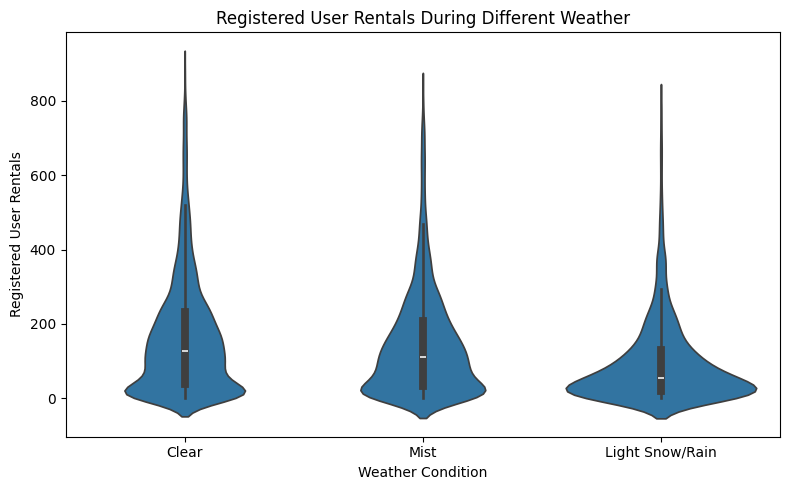

In [14]:
# Plot 8: Violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x='weather_name', y='registered', data=df, order=['Clear', 'Mist', 'Light Snow/Rain'])
plt.title('Registered User Rentals During Different Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Registered User Rentals')
plt.tight_layout()
plt.savefig('../figures/plot8_violin_weather.png', dpi=200)
plt.show()


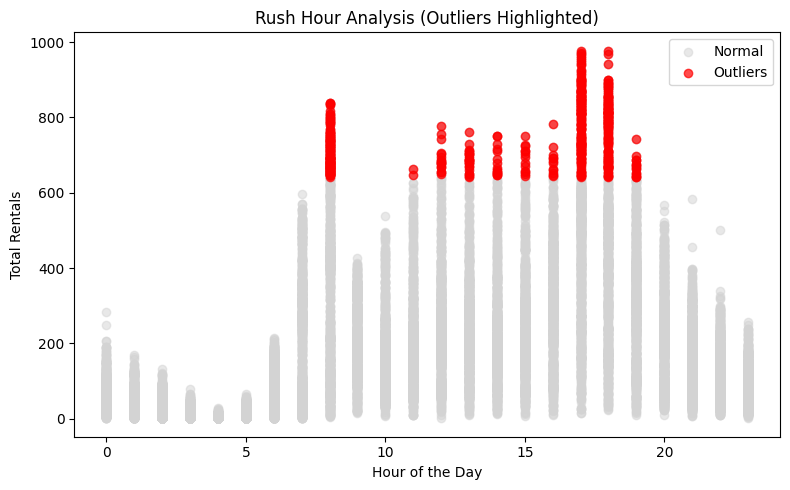

In [15]:
# Plot 9: Anomaly highlighting
plt.figure(figsize=(8,5))
plt.scatter(df['hr'], df['cnt'], c='lightgray', label='Normal', alpha=0.5)
outliers_df = df[df['cnt'] > upper_bound]
plt.scatter(outliers_df['hr'], outliers_df['cnt'], c='red', label='Outliers', alpha=0.7)
plt.title('Rush Hour Analysis (Outliers Highlighted)')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Rentals')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/plot9_scatter_outliers.png', dpi=200)
plt.show()


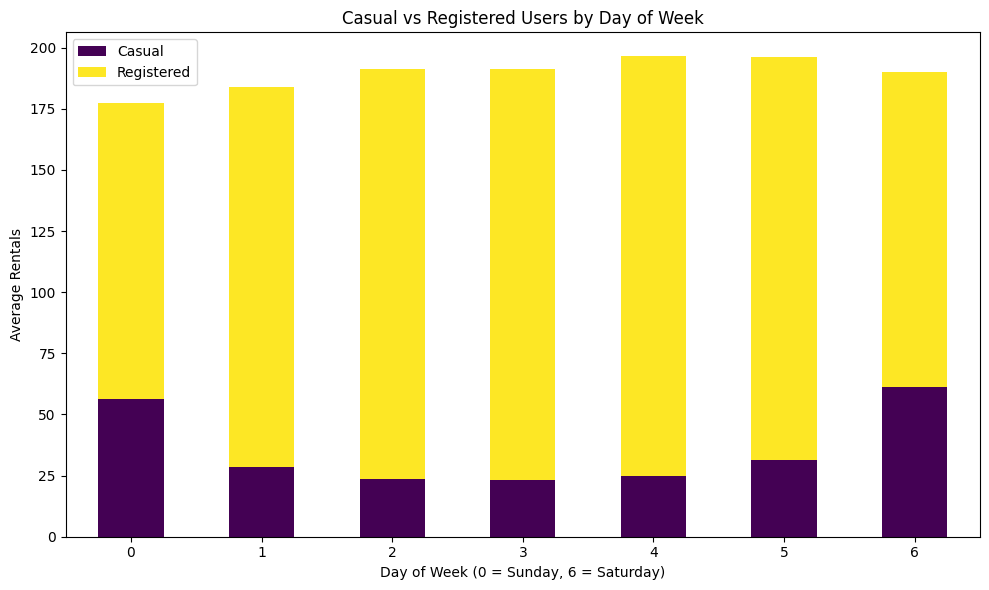

In [16]:
# Plot 10: Aggregated Stacked Bar
plt.figure(figsize=(10,6))
day_avg = df.groupby('weekday')[['casual', 'registered']].mean().reset_index()
day_avg.plot(x='weekday', y=['casual', 'registered'], kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Casual vs Registered Users by Day of Week')
plt.xlabel('Day of Week (0 = Sunday, 6 = Saturday)')
plt.ylabel('Average Rentals')
plt.legend(['Casual', 'Registered'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/plot10_stacked_bar.png', dpi=200)
plt.show()


For a comprehensive breakdown of the insights and interpretations derived from these plots, please refer to the final EDA Report (DOCX).